# Gaussian Set Operations — Visual Experiments

This notebook turns `12-gaussian-set-operations.md` into small, visual experiments.
It focuses on one central idea: once a scene is represented as an explicit set of Gaussian primitives,
we can operate on the set itself instead of only nudging parameters in place.

The experiments use 2D Gaussian splats as a teaching surrogate for 3DGS.
That keeps the geometry simple enough to inspect while preserving the intuition behind add, split, prune, merge, and local editing.


In [1]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 115,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.25,
})
print('Setup complete.')


Setup complete.


### What you see

The setup cell fixes the random seed and plotting style.
That matters because several experiments compare two nearly similar Gaussian sets,
and the differences are easiest to trust when the notebook is visually consistent and reproducible.


---

We first define a small Gaussian-rendering toolkit.
Each primitive has a center, anisotropic scale, rotation, amplitude, color, and an optional group label.
This is enough to reason about set-level edits without bringing in the full 3D camera pipeline.


In [2]:
X_MIN, X_MAX = -3.0, 3.0
Y_MIN, Y_MAX = -2.2, 2.2
GRID_W, GRID_H = 240, 180


def make_grid():
    xs = np.linspace(X_MIN, X_MAX, GRID_W)
    ys = np.linspace(Y_MIN, Y_MAX, GRID_H)
    xx, yy = np.meshgrid(xs, ys)
    return xx, yy


XX, YY = make_grid()


def covariance_from_axes(scale_x, scale_y, angle_rad):
    rot = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad),  np.cos(angle_rad)],
    ])
    scales = np.diag([scale_x ** 2, scale_y ** 2])
    return rot @ scales @ rot.T


def gaussian_density(mean, cov, amplitude=1.0):
    pos = np.stack([XX - mean[0], YY - mean[1]], axis=-1)
    inv_cov = np.linalg.inv(cov)
    exponent = np.einsum('...i,ij,...j->...', pos, inv_cov, pos)
    return amplitude * np.exp(-0.5 * exponent)


def render_intensity(gaussians):
    image = np.zeros((GRID_H, GRID_W), dtype=float)
    for g in gaussians:
        cov = covariance_from_axes(g['sx'], g['sy'], g['theta'])
        image += gaussian_density(g['mean'], cov, g.get('amp', 1.0))
    return image


def plot_intensity(ax, image, title, cmap='YlOrRd', vmax=None):
    if vmax is None:
        vmax = max(1.0, float(image.max()))
    im = ax.imshow(
        image,
        extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
        origin='lower',
        cmap=cmap,
        vmin=float(image.min()) if cmap == 'RdBu_r' else 0.0,
        vmax=vmax,
        aspect='auto',
    )
    ax.set_title(title)
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')
    return im


def add_ellipse(ax, mean, sx, sy, theta, color, label=None, alpha=0.18):
    ell = mpatches.Ellipse(
        xy=mean,
        width=4.0 * sx,
        height=4.0 * sy,
        angle=np.degrees(theta),
        facecolor=color,
        edgecolor=color,
        linewidth=2,
        alpha=alpha,
        label=label,
    )
    ax.add_patch(ell)
    ax.scatter([mean[0]], [mean[1]], color=color, s=30, zorder=3)


def plot_state(ax, gaussians, title, annotate_ids=False):
    for g in gaussians:
        add_ellipse(ax, g['mean'], g['sx'], g['sy'], g['theta'], g['color'], label=g.get('group'))
        if annotate_ids and 'name' in g:
            ax.text(g['mean'][0] + 0.05, g['mean'][1] + 0.05, g['name'], color=g['color'], fontsize=9)
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')


def mse(a, b):
    return float(np.mean((a - b) ** 2))


print('Helper functions ready.')


Helper functions ready.


### What you see

The helper cell gives us two complementary views of a Gaussian set:
its rendered image and its primitive layout.
That dual view is useful because set operations change both the scene output and the structure of the latent representation.


---

## Experiment 1: Why does a large coarse Gaussian need to be split?

Question this answers: when one Gaussian tries to explain a region that actually contains multiple local peaks,
why is splitting more effective than only tuning its parameters?

We compare a target scene with two nearby bright structures against a coarse one-Gaussian approximation,
then replace that single primitive with two smaller ones.


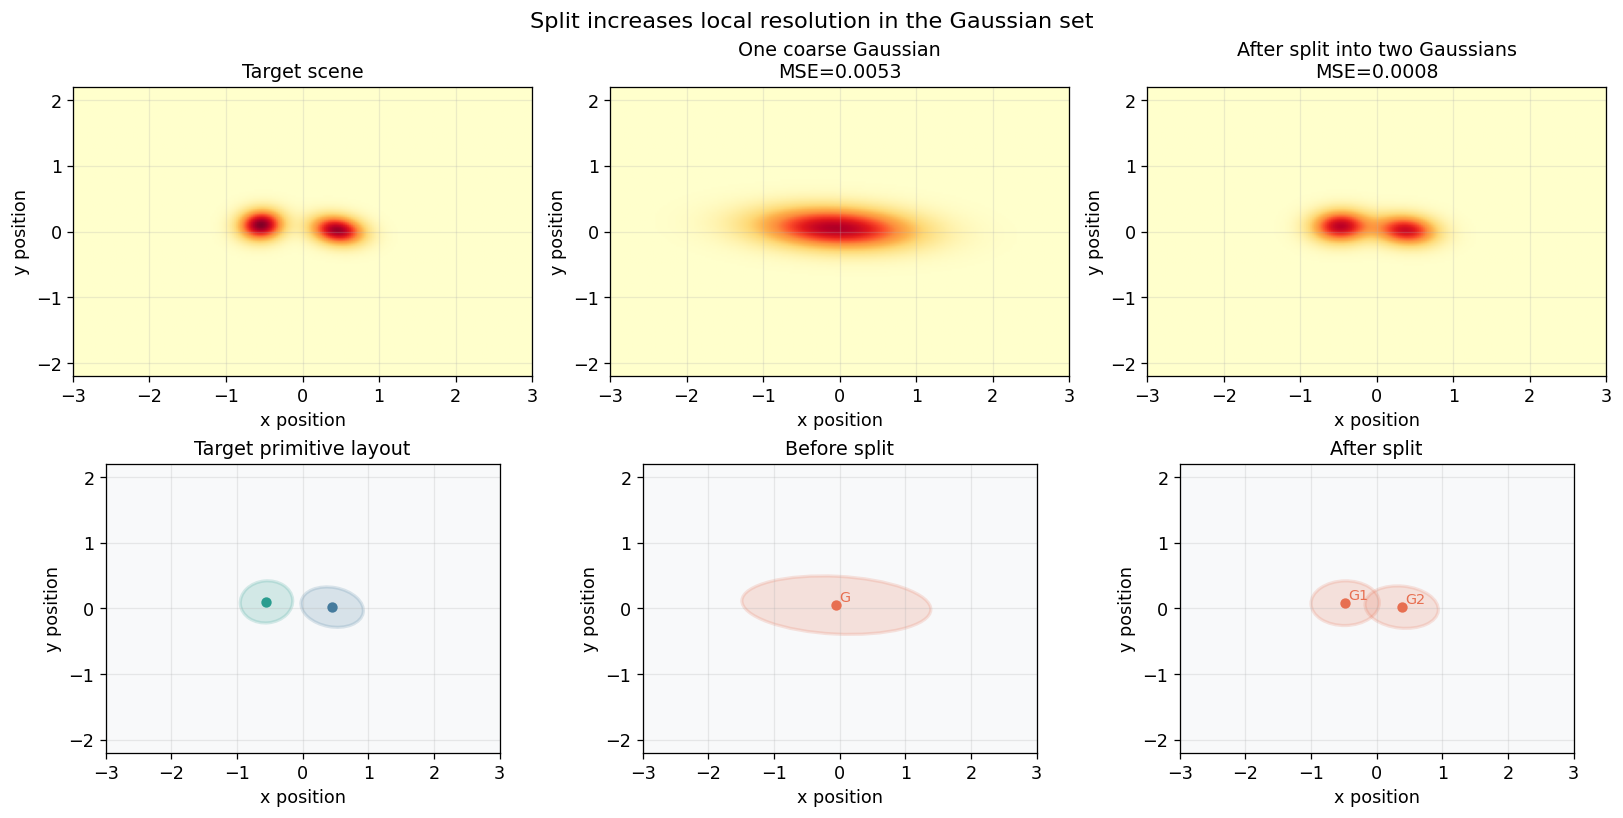

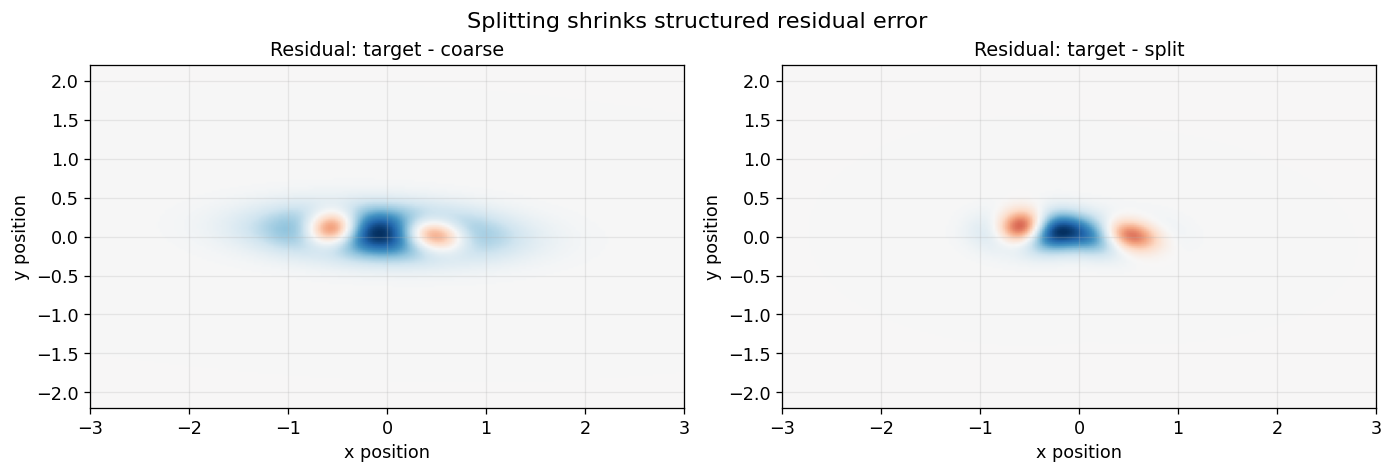

In [3]:
target_split = [
    {'mean': (-0.55, 0.10), 'sx': 0.20, 'sy': 0.16, 'theta': 0.10, 'amp': 1.0, 'color': '#2a9d8f'},
    {'mean': ( 0.45, 0.02), 'sx': 0.24, 'sy': 0.15, 'theta': -0.18, 'amp': 0.95, 'color': '#457b9d'},
]
coarse_one = [
    {'mean': (-0.05, 0.05), 'sx': 0.72, 'sy': 0.22, 'theta': -0.05, 'amp': 0.90, 'color': '#e76f51', 'name': 'G'},
]
split_two = [
    {'mean': (-0.48, 0.08), 'sx': 0.26, 'sy': 0.17, 'theta': 0.02, 'amp': 0.87, 'color': '#e76f51', 'name': 'G1'},
    {'mean': ( 0.38, 0.02), 'sx': 0.28, 'sy': 0.16, 'theta': -0.10, 'amp': 0.82, 'color': '#e76f51', 'name': 'G2'},
]

target_img = render_intensity(target_split)
coarse_img = render_intensity(coarse_one)
split_img = render_intensity(split_two)
residual_coarse = target_img - coarse_img
residual_split = target_img - split_img

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
plot_intensity(axes[0, 0], target_img, 'Target scene')
plot_state(axes[1, 0], target_split, 'Target primitive layout')
plot_intensity(axes[0, 1], coarse_img, f'One coarse Gaussian\nMSE={mse(target_img, coarse_img):.4f}')
plot_state(axes[1, 1], coarse_one, 'Before split', annotate_ids=True)
plot_intensity(axes[0, 2], split_img, f'After split into two Gaussians\nMSE={mse(target_img, split_img):.4f}')
plot_state(axes[1, 2], split_two, 'After split', annotate_ids=True)
fig.suptitle('Split increases local resolution in the Gaussian set', fontsize=14)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
plot_intensity(axes[0], residual_coarse, 'Residual: target - coarse', cmap='RdBu_r', vmax=np.max(np.abs(residual_coarse)))
plot_intensity(axes[1], residual_split, 'Residual: target - split', cmap='RdBu_r', vmax=np.max(np.abs(residual_split)))
fig.suptitle('Splitting shrinks structured residual error', fontsize=14)
plt.show()


### What you see

The one-Gaussian approximation can only place one broad support over the region,
so it smooths over the fact that the target really contains two distinct local structures.
After the split, the set gains one extra degree of locality: each child Gaussian can specialize to one peak.

The residual heatmaps make the same point more formally.
Before the split, the error is organized and structured, which means the model is under-resolved.
After the split, the residual is weaker and less coherent because the Gaussian set now has enough local capacity to follow the scene.


---

## Experiment 2: Why do we need add or clone operations?

Question this answers: what happens when a region of the scene has no primitive assigned to it yet?

We create a target scene with three structures but start from a Gaussian set that only covers two of them.
The added Gaussian acts like a localized capacity increase exactly where the residual demands it.


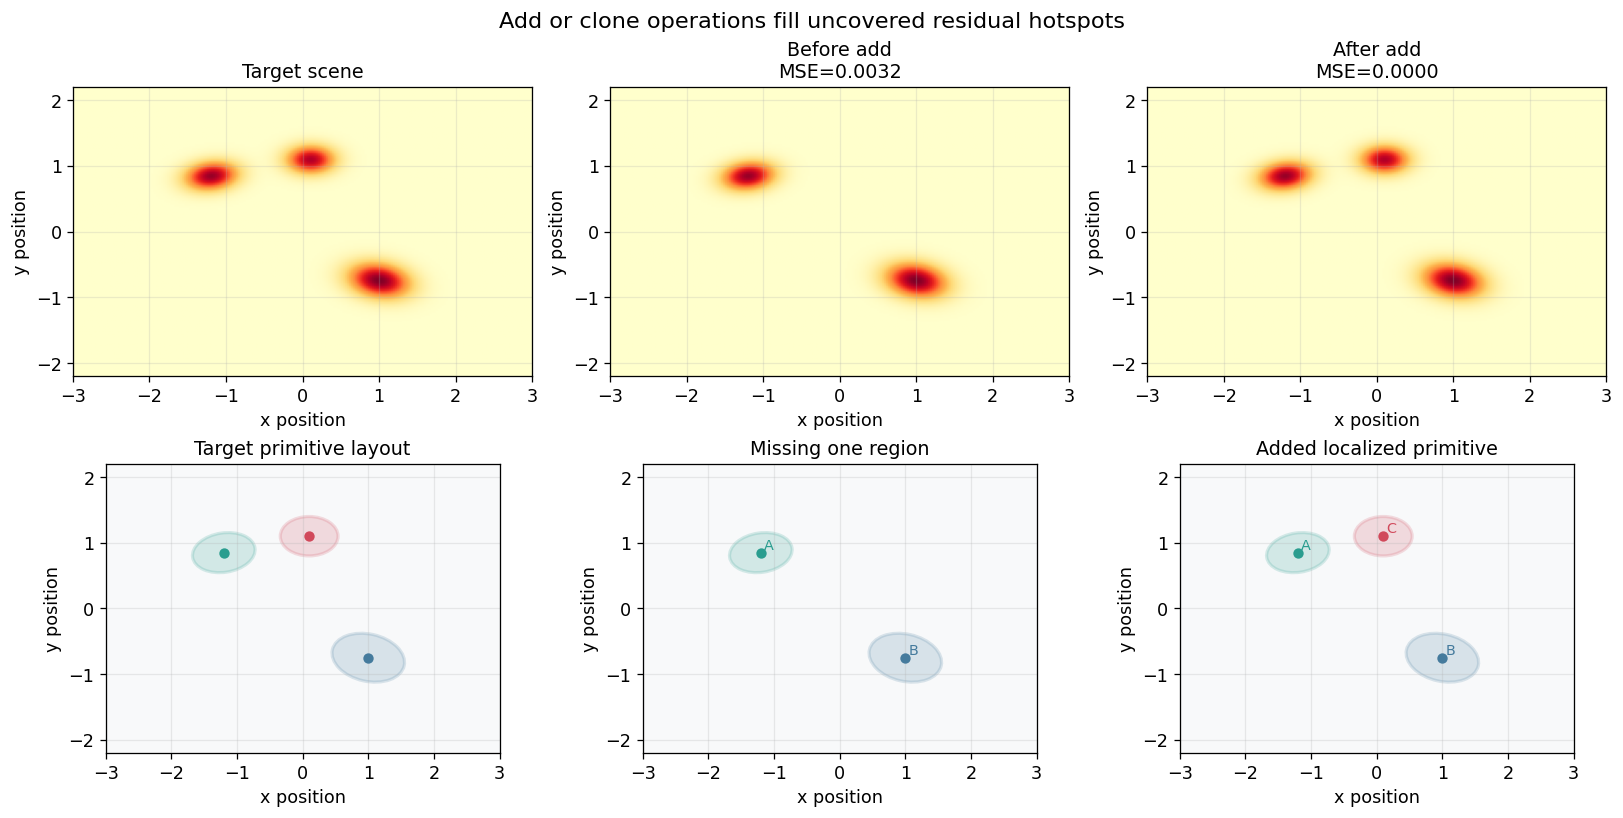

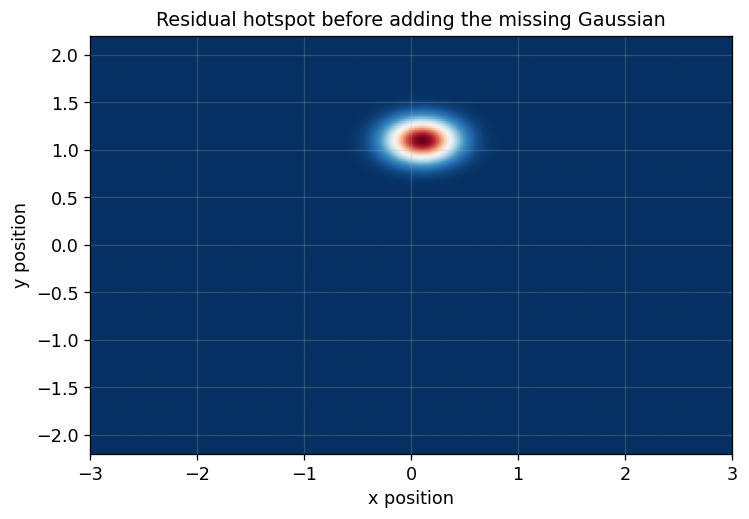

In [4]:
target_add = [
    {'mean': (-1.2, 0.85), 'sx': 0.24, 'sy': 0.15, 'theta': 0.15, 'amp': 0.95, 'color': '#2a9d8f'},
    {'mean': ( 1.0,-0.75), 'sx': 0.28, 'sy': 0.18, 'theta':-0.22, 'amp': 1.00, 'color': '#457b9d'},
    {'mean': ( 0.1, 1.10), 'sx': 0.22, 'sy': 0.15, 'theta': 0.00, 'amp': 0.90, 'color': '#d1495b'},
]
undercovered = [
    {'mean': (-1.2, 0.85), 'sx': 0.24, 'sy': 0.15, 'theta': 0.15, 'amp': 0.95, 'color': '#2a9d8f', 'name': 'A'},
    {'mean': ( 1.0,-0.75), 'sx': 0.28, 'sy': 0.18, 'theta':-0.22, 'amp': 1.00, 'color': '#457b9d', 'name': 'B'},
]
with_added = undercovered + [
    {'mean': ( 0.1, 1.10), 'sx': 0.22, 'sy': 0.15, 'theta': 0.00, 'amp': 0.90, 'color': '#d1495b', 'name': 'C'},
]

target_add_img = render_intensity(target_add)
under_img = render_intensity(undercovered)
added_img = render_intensity(with_added)
residual_add = target_add_img - under_img

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
plot_intensity(axes[0, 0], target_add_img, 'Target scene')
plot_state(axes[1, 0], target_add, 'Target primitive layout')
plot_intensity(axes[0, 1], under_img, f'Before add\nMSE={mse(target_add_img, under_img):.4f}')
plot_state(axes[1, 1], undercovered, 'Missing one region', annotate_ids=True)
plot_intensity(axes[0, 2], added_img, f'After add\nMSE={mse(target_add_img, added_img):.4f}')
plot_state(axes[1, 2], with_added, 'Added localized primitive', annotate_ids=True)
fig.suptitle('Add or clone operations fill uncovered residual hotspots', fontsize=14)
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 4.4), constrained_layout=True)
plot_intensity(ax, residual_add, 'Residual hotspot before adding the missing Gaussian', cmap='RdBu_r', vmax=np.max(np.abs(residual_add)))
plt.show()


### What you see

The residual map before the add operation contains one clear hotspot: a whole visible structure has no primitive assigned to it.
Parameter tuning alone cannot invent support in that empty region if the current set never places a Gaussian there.
Adding a new primitive is the natural set-level fix.

This is why densification is more than cosmetic.
An explicit Gaussian set can respond to missing structure by literally inserting a new element where the evidence accumulates,
which is harder to express in a global implicit field without revising the whole function.


---

## Experiment 3: Why is pruning a first-class operation instead of just cleanup?

Question this answers: when some Gaussians contribute almost nothing or act as floaters,
can we remove them without materially changing the scene?

We measure each primitive by its rendered mass and compare the full set to a pruned one.


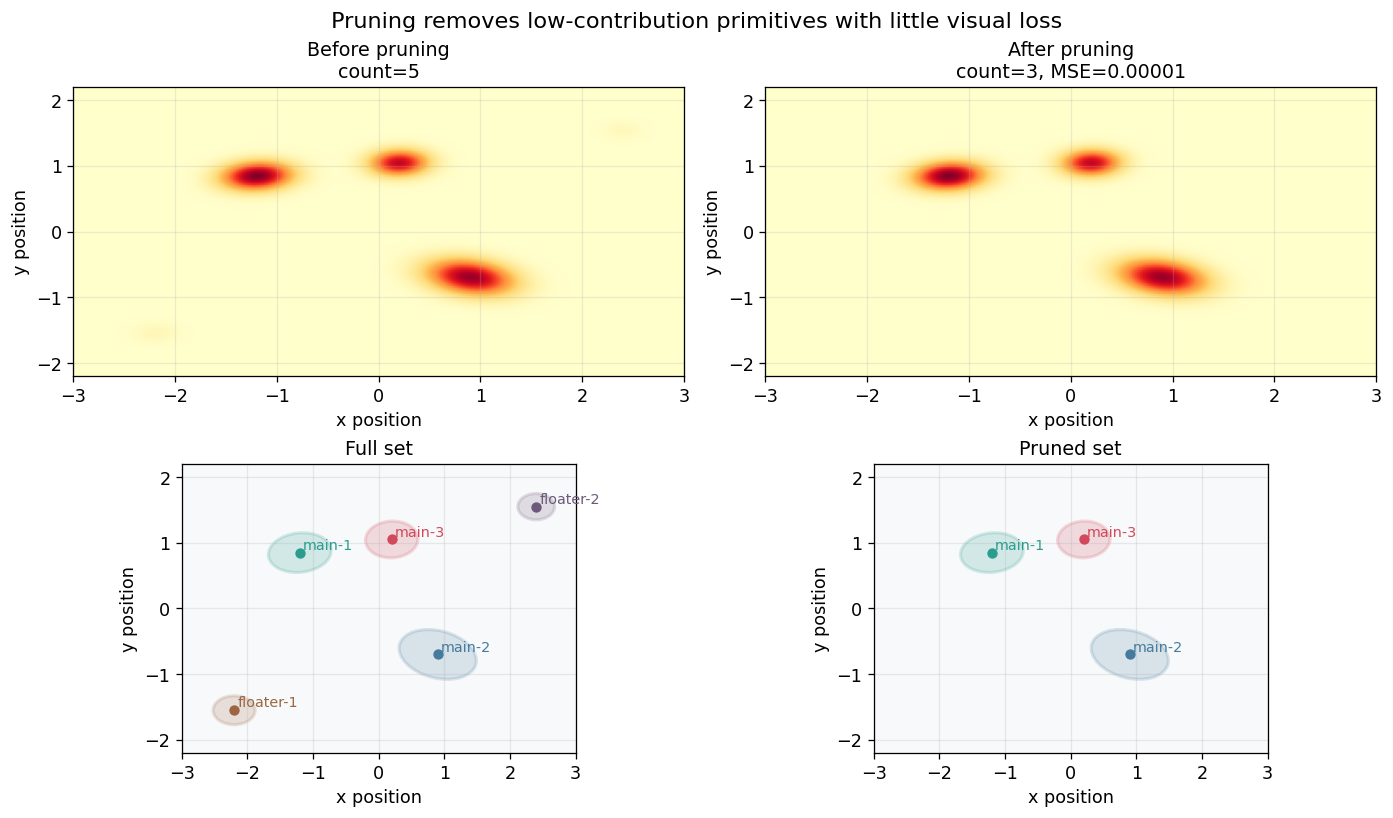

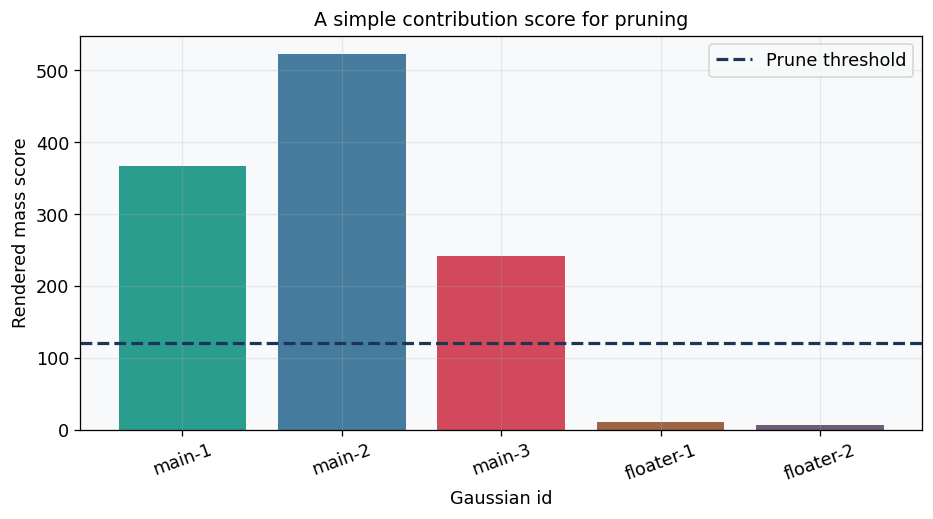

In [5]:
prune_scene = [
    {'mean': (-1.2, 0.85), 'sx': 0.24, 'sy': 0.15, 'theta': 0.10, 'amp': 1.00, 'color': '#2a9d8f', 'name': 'main-1'},
    {'mean': ( 0.9,-0.70), 'sx': 0.30, 'sy': 0.18, 'theta':-0.25, 'amp': 0.95, 'color': '#457b9d', 'name': 'main-2'},
    {'mean': ( 0.2, 1.05), 'sx': 0.20, 'sy': 0.14, 'theta': 0.05, 'amp': 0.85, 'color': '#d1495b', 'name': 'main-3'},
    {'mean': (-2.2,-1.55), 'sx': 0.16, 'sy': 0.11, 'theta': 0.00, 'amp': 0.06, 'color': '#9c6644', 'name': 'floater-1'},
    {'mean': ( 2.4, 1.55), 'sx': 0.14, 'sy': 0.10, 'theta': 0.00, 'amp': 0.05, 'color': '#6d597a', 'name': 'floater-2'},
]

def gaussian_mass(g):
    img = render_intensity([g])
    return float(img.sum())

masses = np.array([gaussian_mass(g) for g in prune_scene])
keep_mask = masses >= 120.0
pruned_scene = [g for g, keep in zip(prune_scene, keep_mask) if keep]
prune_full_img = render_intensity(prune_scene)
prune_pruned_img = render_intensity(pruned_scene)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
plot_intensity(axes[0, 0], prune_full_img, f'Before pruning\ncount={len(prune_scene)}')
plot_state(axes[1, 0], prune_scene, 'Full set', annotate_ids=True)
plot_intensity(axes[0, 1], prune_pruned_img, f'After pruning\ncount={len(pruned_scene)}, MSE={mse(prune_full_img, prune_pruned_img):.5f}')
plot_state(axes[1, 1], pruned_scene, 'Pruned set', annotate_ids=True)
fig.suptitle('Pruning removes low-contribution primitives with little visual loss', fontsize=14)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.4), constrained_layout=True)
labels = [g['name'] for g in prune_scene]
colors = [g['color'] for g in prune_scene]
ax.bar(labels, masses, color=colors)
ax.axhline(120.0, color='#1d3557', linestyle='--', linewidth=2, label='Prune threshold')
ax.set_title('A simple contribution score for pruning')
ax.set_xlabel('Gaussian id')
ax.set_ylabel('Rendered mass score')
ax.legend()
plt.xticks(rotation=20)
plt.show()


### What you see

The two small floaters sit far from the main structures and contribute very little rendered mass.
Removing them barely changes the image, but it does reduce the cardinality of the state.
That is exactly the logic behind pruning-based 3DGS compression pipelines.

The key point is that pruning is not just deleting random Gaussians.
It is a set decision based on some importance score, whether that score comes from opacity, reconstruction sensitivity, uncertainty, or a learned criterion.


---

## Experiment 4: What do we gain and lose when we merge nearby Gaussians?

Question this answers: if several small Gaussians describe one compact object part,
can we replace them with a coarser representative and save memory?

We compare a detailed four-Gaussian cluster against a one-Gaussian merged approximation.


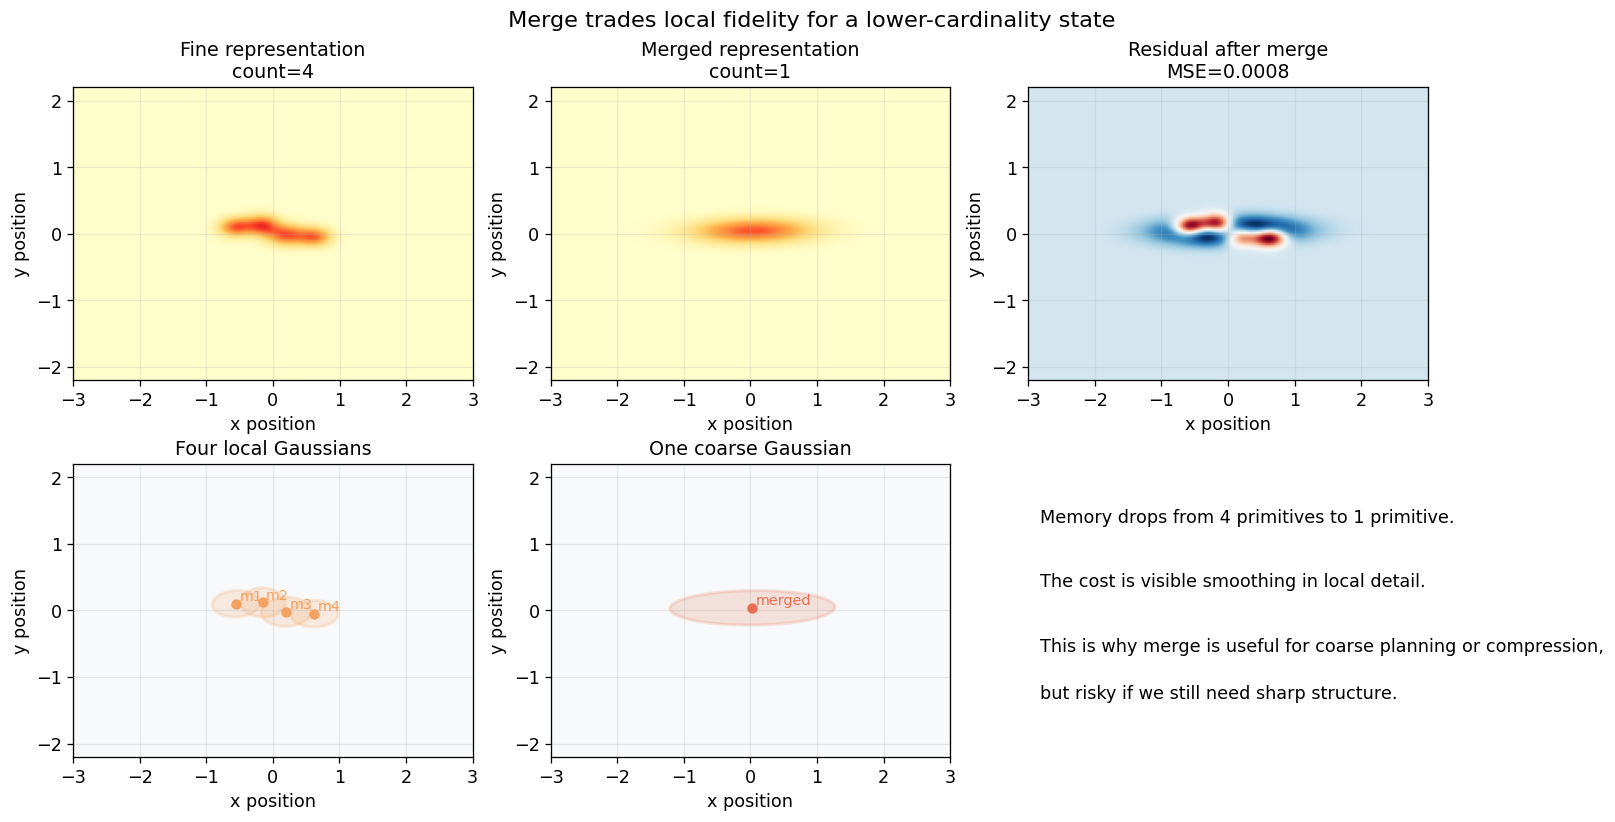

In [6]:
fine_cluster = [
    {'mean': (-0.55, 0.10), 'sx': 0.18, 'sy': 0.10, 'theta': 0.05, 'amp': 0.60, 'color': '#f4a261', 'name': 'm1'},
    {'mean': (-0.15, 0.12), 'sx': 0.17, 'sy': 0.11, 'theta':-0.02, 'amp': 0.62, 'color': '#f4a261', 'name': 'm2'},
    {'mean': ( 0.20,-0.02), 'sx': 0.19, 'sy': 0.11, 'theta': 0.03, 'amp': 0.58, 'color': '#f4a261', 'name': 'm3'},
    {'mean': ( 0.62,-0.05), 'sx': 0.18, 'sy': 0.10, 'theta': 0.00, 'amp': 0.56, 'color': '#f4a261', 'name': 'm4'},
]
merged_one = [
    {'mean': (0.03, 0.04), 'sx': 0.62, 'sy': 0.13, 'theta': 0.01, 'amp': 0.62, 'color': '#e76f51', 'name': 'merged'},
]
fine_img = render_intensity(fine_cluster)
merged_img = render_intensity(merged_one)
merge_residual = fine_img - merged_img

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
plot_intensity(axes[0, 0], fine_img, f'Fine representation\ncount={len(fine_cluster)}')
plot_state(axes[1, 0], fine_cluster, 'Four local Gaussians', annotate_ids=True)
plot_intensity(axes[0, 1], merged_img, f'Merged representation\ncount={len(merged_one)}')
plot_state(axes[1, 1], merged_one, 'One coarse Gaussian', annotate_ids=True)
plot_intensity(axes[0, 2], merge_residual, f'Residual after merge\nMSE={mse(fine_img, merged_img):.4f}', cmap='RdBu_r', vmax=np.max(np.abs(merge_residual)))
axes[1, 2].axis('off')
axes[1, 2].text(0.03, 0.80, 'Memory drops from 4 primitives to 1 primitive.', fontsize=11)
axes[1, 2].text(0.03, 0.58, 'The cost is visible smoothing in local detail.', fontsize=11)
axes[1, 2].text(0.03, 0.36, 'This is why merge is useful for coarse planning or compression,', fontsize=11)
axes[1, 2].text(0.03, 0.20, 'but risky if we still need sharp structure.', fontsize=11)
fig.suptitle('Merge trades local fidelity for a lower-cardinality state', fontsize=14)
plt.show()


### What you see

The merged Gaussian does capture the rough location and elongation of the cluster,
but it cannot preserve the fine local undulations that four separate primitives can express.
This is the central merge trade-off: fewer primitives and cheaper memory, but a coarser state.

That trade-off is not automatically bad.
For a planning system or a compact rollout memory, a coarse merged state may be exactly what we want,
provided we know how much detail we are willing to sacrifice and when to split again later.


---

## Experiment 5: Why is an explicit set naturally editable?

Question this answers: if the scene is already decomposed into Gaussian groups,
what does a local edit look like?

We create a simple scene with two object groups and perform an object removal operation by deleting one group's primitives.


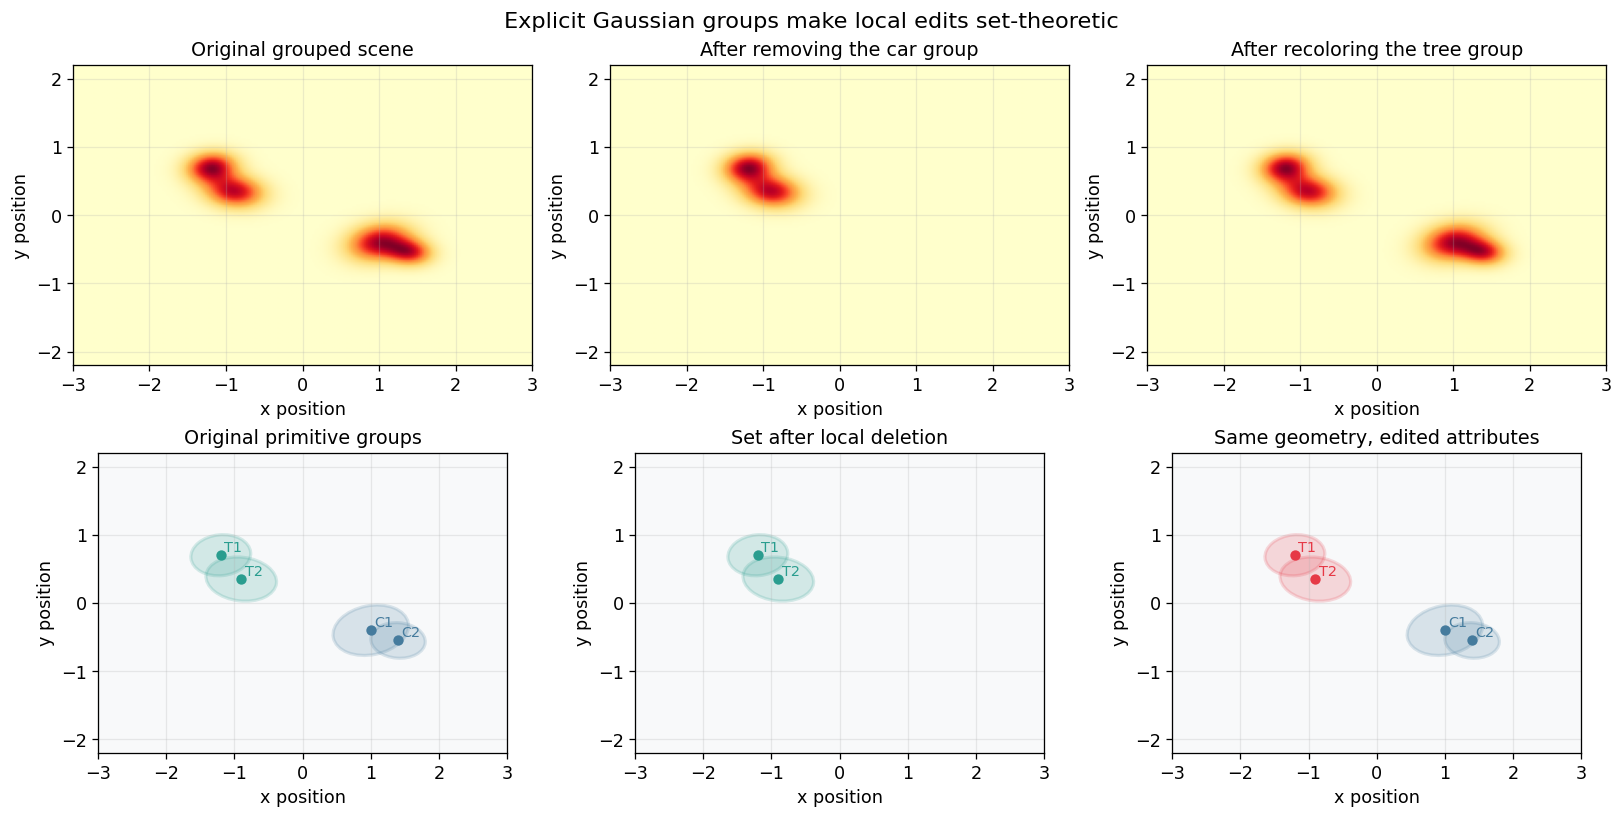

In [7]:
editable_scene = [
    {'mean': (-1.2, 0.70), 'sx': 0.22, 'sy': 0.15, 'theta': 0.10, 'amp': 0.95, 'color': '#2a9d8f', 'group': 'tree', 'name': 'T1'},
    {'mean': (-0.9, 0.35), 'sx': 0.26, 'sy': 0.16, 'theta':-0.12, 'amp': 0.88, 'color': '#2a9d8f', 'group': 'tree', 'name': 'T2'},
    {'mean': ( 1.0,-0.40), 'sx': 0.28, 'sy': 0.18, 'theta': 0.20, 'amp': 0.92, 'color': '#457b9d', 'group': 'car',  'name': 'C1'},
    {'mean': ( 1.4,-0.55), 'sx': 0.20, 'sy': 0.13, 'theta':-0.08, 'amp': 0.76, 'color': '#457b9d', 'group': 'car',  'name': 'C2'},
]
removed_car_scene = [g for g in editable_scene if g['group'] != 'car']
recolor_tree_scene = [
    {**g, 'color': '#e63946'} if g['group'] == 'tree' else g
    for g in editable_scene
]

editable_img = render_intensity(editable_scene)
removed_img = render_intensity(removed_car_scene)
recolor_img = render_intensity(recolor_tree_scene)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
plot_intensity(axes[0, 0], editable_img, 'Original grouped scene')
plot_state(axes[1, 0], editable_scene, 'Original primitive groups', annotate_ids=True)
plot_intensity(axes[0, 1], removed_img, 'After removing the car group')
plot_state(axes[1, 1], removed_car_scene, 'Set after local deletion', annotate_ids=True)
plot_intensity(axes[0, 2], recolor_img, 'After recoloring the tree group')
plot_state(axes[1, 2], recolor_tree_scene, 'Same geometry, edited attributes', annotate_ids=True)
fig.suptitle('Explicit Gaussian groups make local edits set-theoretic', fontsize=14)
plt.show()


### What you see

Once the scene is decomposed into explicit Gaussian groups, local editing becomes a direct set operation.
Removing the car means deleting its subset. Recoloring the tree means editing only the attributes of that subset.
Nothing forces us to re-interpret the entire scene globally.

This is the practical reason Gaussian set operations matter for world models and editors.
The representation already lives in a form where locality, grouping, and identity can be manipulated at the primitive level.


---

## Summary / Key Takeaways

- Split resolves under-modeled regions by replacing one coarse primitive with several finer ones.
- Add or clone inserts local capacity exactly where residual error reveals missing support.
- Prune removes low-contribution primitives and turns set cardinality into an optimization target.
- Merge is the natural compression inverse of split, but it always trades detail for compactness.
- An explicit Gaussian set is naturally editable because local scene changes map to local subset operations.
